In [3]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/content/train_and_test2.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0



Box plots for numerical features (Outlier Identification):


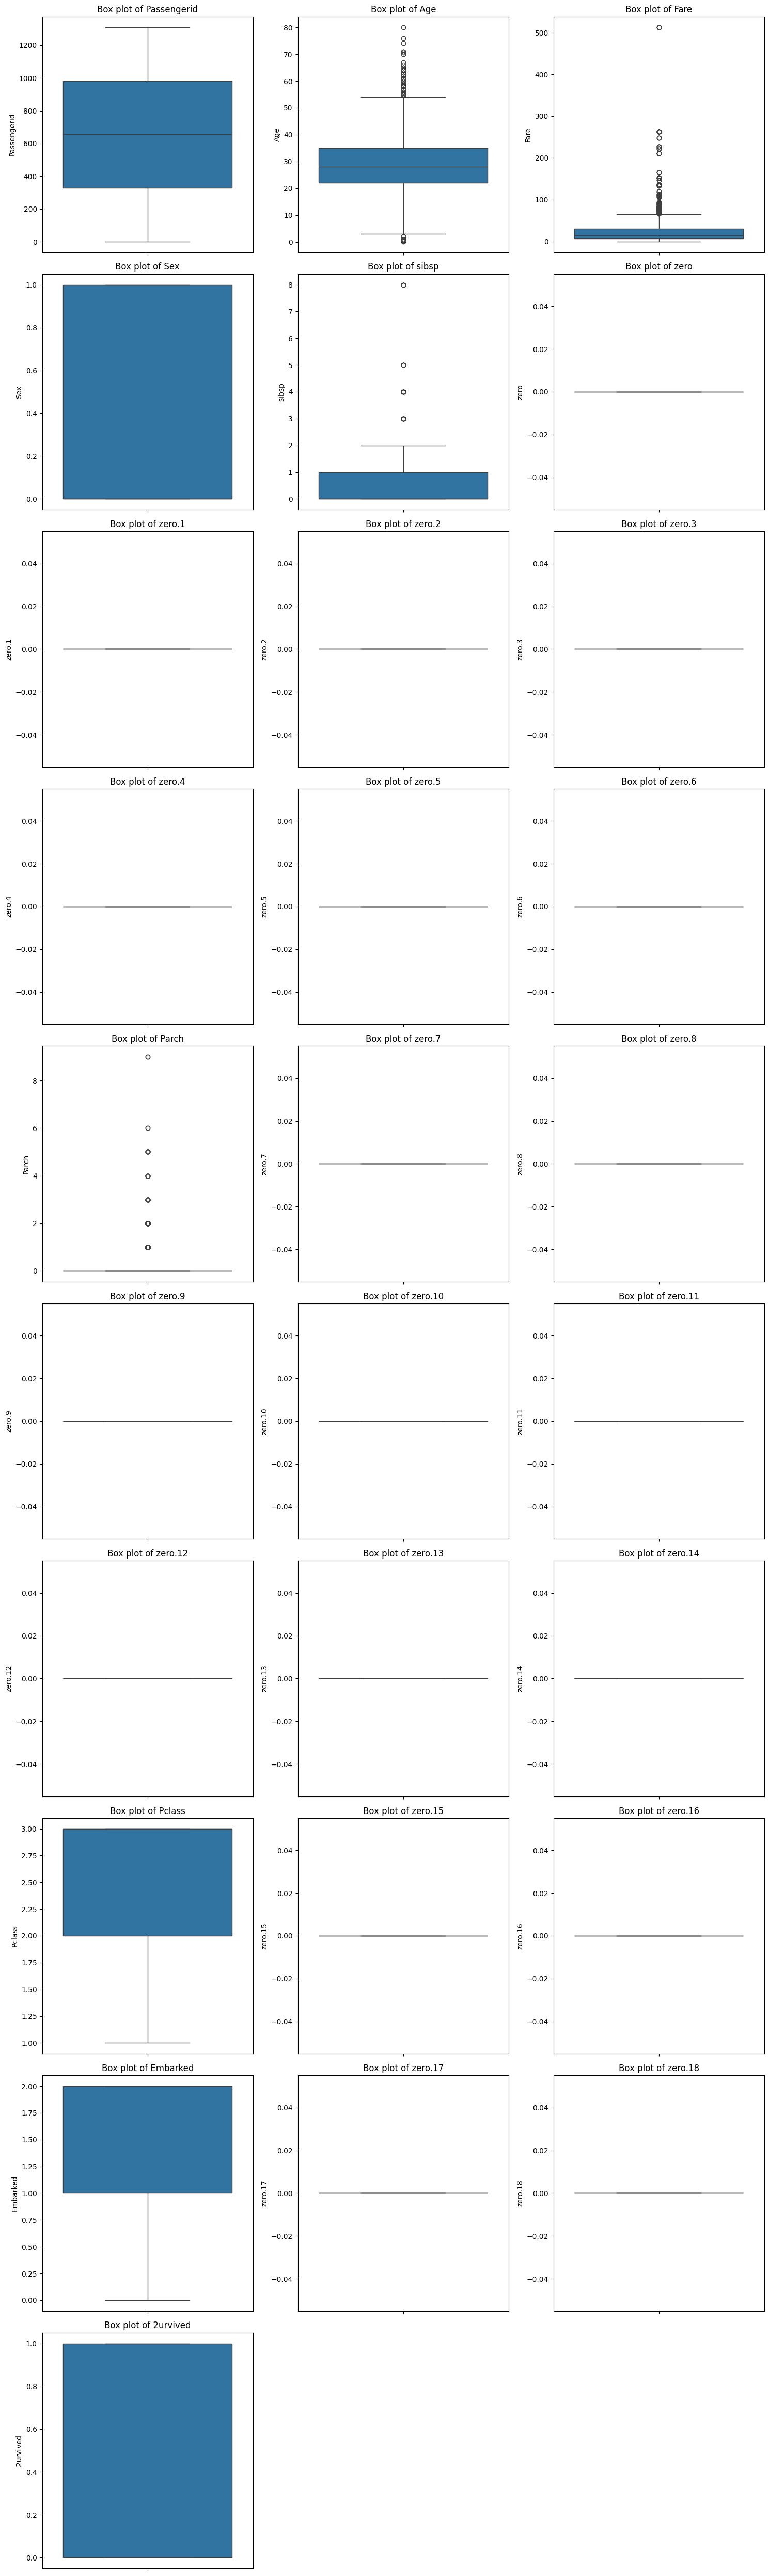

In [4]:
# Identify numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['number']).columns

if not numerical_cols.empty:
    print("\nBox plots for numerical features (Outlier Identification):")
    plt.figure(figsize=(15, 5 * ((len(numerical_cols) + 2) // 3)))
    for i, col in enumerate(numerical_cols):
        plt.subplot((len(numerical_cols) + 2) // 3, 3, i + 1)
        sns.boxplot(y=df[col])
        plt.title(f'Box plot of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found for outlier identification.")


Histograms for numerical features:


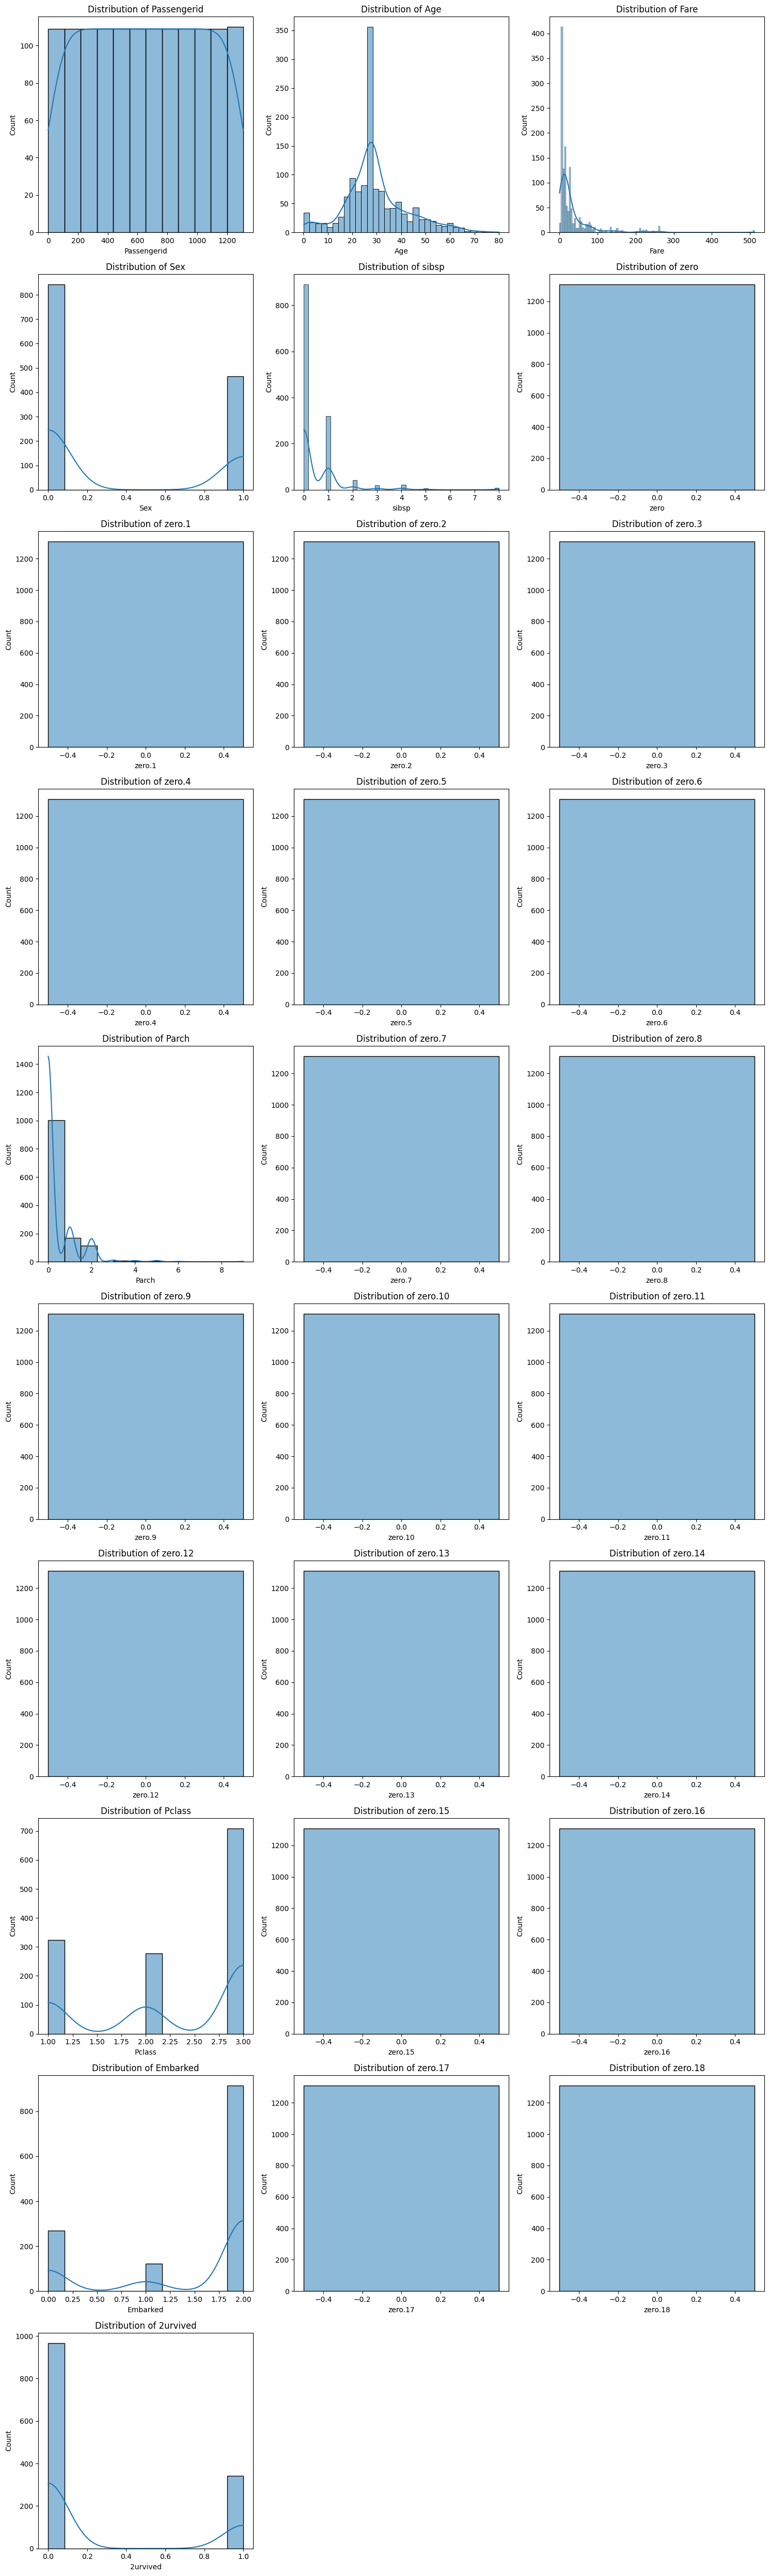

No categorical columns found for bar plots.


In [5]:
# Histograms for numerical columns
if not numerical_cols.empty:
    print("\nHistograms for numerical features:")
    plt.figure(figsize=(15, 5 * ((len(numerical_cols) + 2) // 3)))
    for i, col in enumerate(numerical_cols):
        plt.subplot((len(numerical_cols) + 2) // 3, 3, i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found for histograms.")

# Bar plots for categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if not categorical_cols.empty:
    print("\nBar plots for categorical features:")
    plt.figure(figsize=(15, 5 * ((len(categorical_cols) + 2) // 3)))
    for i, col in enumerate(categorical_cols):
        plt.subplot((len(categorical_cols) + 2) // 3, 3, i + 1)
        df[col].value_counts().plot(kind='bar')
        plt.title(f'Counts of {col}')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found for bar plots.")


Correlation Matrix of numerical features:


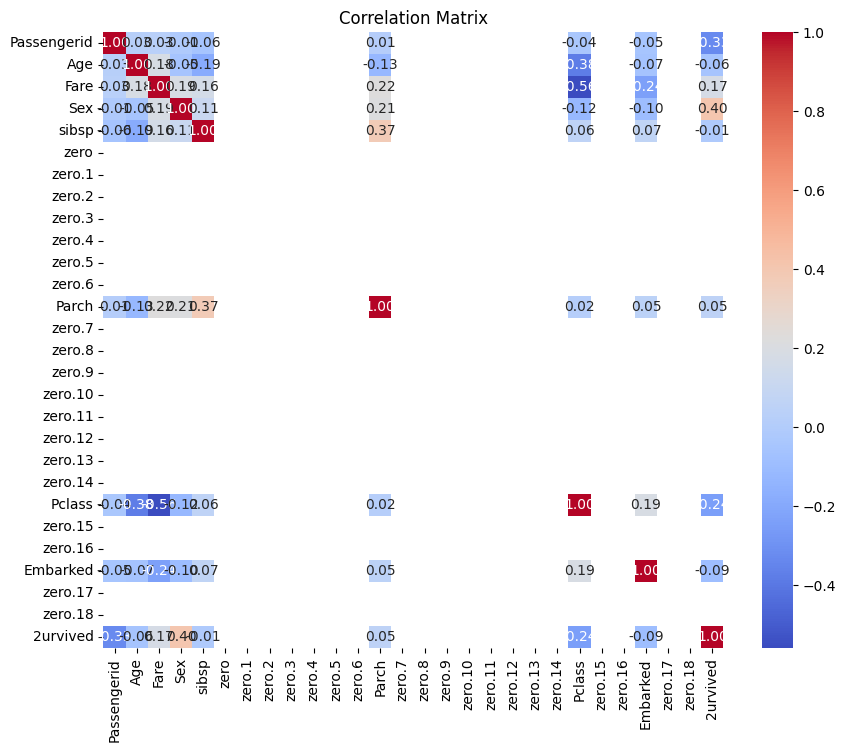

Too many numerical columns for a readable pairplot. Consider selecting a subset manually.


In [6]:
# Correlation Matrix for numerical features
if not numerical_cols.empty and len(numerical_cols) > 1:
    print("\nCorrelation Matrix of numerical features:")
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix')
    plt.show()
elif not numerical_cols.empty and len(numerical_cols) == 1:
    print("Only one numerical column found. Correlation matrix requires at least two numerical columns.")
else:
    print("No numerical columns found for correlation matrix.")

# Pairplot for a subset of numerical features (if too many, it might be slow)
if not numerical_cols.empty and len(numerical_cols) > 1 and len(numerical_cols) <= 5: # Limit for readability
    print("\nPairplot for a subset of numerical features:")
    sns.pairplot(df[numerical_cols])
    plt.suptitle('Pairplot of Numerical Features', y=1.02) # Adjust title position
    plt.show()
elif not numerical_cols.empty and len(numerical_cols) > 5:
    print("Too many numerical columns for a readable pairplot. Consider selecting a subset manually.")

# Example: Box plots for numerical vs. categorical features (if applicable)
# Replace 'your_categorical_column' and 'your_numerical_column' with actual column names
# if 'your_categorical_column' in df.columns and 'your_numerical_column' in df.columns:
#     plt.figure(figsize=(10, 6))
#     sns.boxplot(x='your_categorical_column', y='your_numerical_column', data=df)
#     plt.title('Numerical Feature Distribution by Category')
#     plt.xticks(rotation=45)
#     plt.show()
# else:
#     print("To perform numerical vs. categorical plotting, specify existing categorical and numerical column names.")
